In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
res = pd.read_csv("./res.csv")
res.head()

,size,algo,modelingtime,encdatabasetime,encqueriestime,buildtime,querytime,params,recall
0,300K,lmi,0.0,0.0,0.0,69.424275,13.291030,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.746390
1,300K,lmi,0.0,0.0,0.0,69.424275,41.543550,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.896710
2,300K,lmi,0.0,0.0,0.0,69.424275,17.144033,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.792793
3,300K,lmi,0.0,0.0,0.0,83.471535,18.176329,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.843773
4,300K,lmi,0.0,0.0,0.0,69.424275,33.305152,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.876627


In [30]:
lmi_res

,size,algo,modelingtime,encdatabasetime,encqueriestime,buildtime,querytime,params,recall,nprobe
0,300K,lmi,0.0,0.0,0.0,69.424275,13.291030,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.746390,3
1,300K,lmi,0.0,0.0,0.0,69.424275,41.543550,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.896710,10
2,300K,lmi,0.0,0.0,0.0,69.424275,17.144033,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.792793,4
4,300K,lmi,0.0,0.0,0.0,69.424275,33.305152,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.876627,8
5,300K,lmi,0.0,0.0,0.0,69.424275,25.421179,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.846383,6
7,300K,lmi,0.0,0.0,0.0,69.424275,20.916047,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.823830,5
8,300K,lmi,0.0,0.0,0.0,69.424275,4.893258,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.507437,1
15,300K,lmi,0.0,0.0,0.0,69.424275,29.720037,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.863193,7
16,300K,lmi,0.0,0.0,0.0,69.424275,9.227108,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.667847,2
18,300K,lmi,0.0,0.0,0.0,69.424275,35.848834,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.887417,9


In [31]:
res.iloc[0]['params']

't1-300K-epochs=15-lr=0.00098-sample=100000-alpha=1.0-chunk_size=100000-kmeans_method=lmi_minibatch-nprobe=3'

In [32]:
# Put nprobe from params into column
res['nprobe'] = res['params'].str.extract('nprobe=(\d+)').astype(int)

# Split by kmeans_method
lmi_res = res[res['params'].str.contains('kmeans_method=lmi')]
faiss_res = res[res['params'].str.contains('kmeans_method=faiss')]

len(lmi_res), len(faiss_res)

(10, 10)

Text(0, 0.5, 'recall')

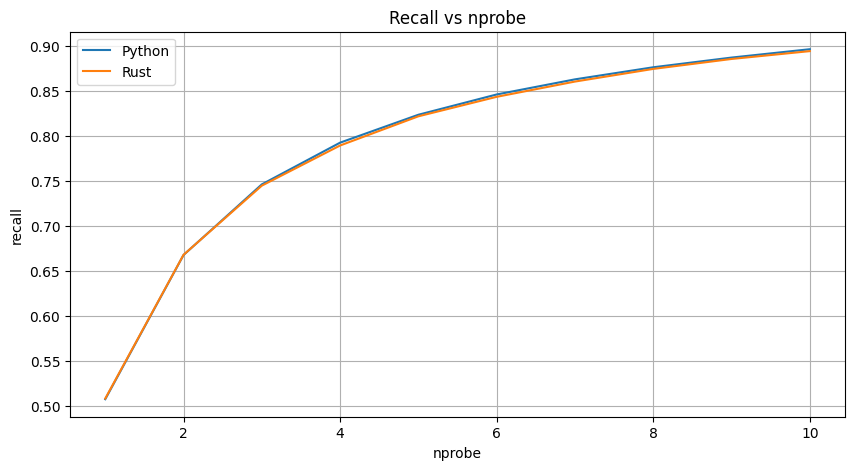

In [33]:
plt.figure(figsize=(10, 5))

plt.title("Recall vs nprobe")

sns.lineplot(x='nprobe', y='recall', data=lmi_res, label='Python')
sns.lineplot(x='nprobe', y='recall', data=faiss_res, label='Rust')

plt.grid(True)

plt.xlabel('nprobe')
plt.ylabel('recall')

Text(0, 0.5, 'querytime')

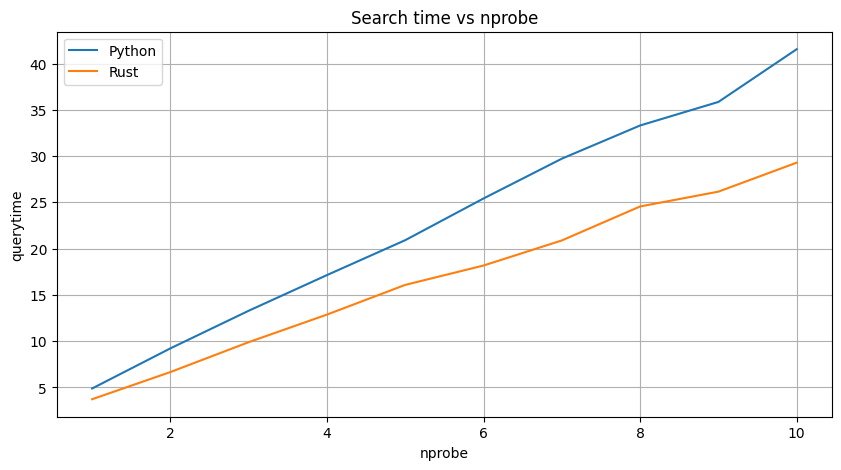

In [34]:
plt.figure(figsize=(10, 5))

plt.title("Search time vs nprobe")

sns.lineplot(x='nprobe', y='querytime', data=lmi_res, label='Python')
sns.lineplot(x='nprobe', y='querytime', data=faiss_res, label='Rust')

plt.grid(True)

plt.xlabel('nprobe')
plt.ylabel('querytime')


In [61]:
faiss_spherical_build_time_s = 22.007
faiss_non_spherical_build_time_s = 21.96
kmeansrs_build_time_s = 41.806
kmeansrs_minibatch_build_time_s = 6.5187


def analyze_kmeans_methods(results_df, methods=None, figsize=(10, 5)):
    if 'nprobe' not in results_df.columns:
        results_df['nprobe'] = results_df['params'].str.extract('nprobe=(\d+)').astype(int)

    results_df['kmeans_method'] = results_df['params'].str.extract('kmeans_method=([^-]+)')

    change_names = {
    'faiss': 'FAISS (Spherical)',
    'faiss_non_spherical': 'FAISS (Non-Spherical)',
    'lmi': 'Kmeans-rs',
    'lmi_minibatch': 'Kmeans-rs (Minibatch)'
    }
    results_df['kmeans_method'] = results_df['kmeans_method'].map(change_names).fillna(results_df['kmeans_method'])
    results_df['kmeans_build_time'] = results_df['kmeans_method'].map({
        'FAISS (Spherical)': faiss_spherical_build_time_s,
        'FAISS (Non-Spherical)': faiss_non_spherical_build_time_s,
        'Kmeans-rs': kmeansrs_build_time_s,
        'Kmeans-rs (Minibatch)': kmeansrs_minibatch_build_time_s
    })

    # Sort alphabetically by method
    results_df = results_df.sort_values(by='kmeans_method')

    # Plot barchart of kmeans_build_time
    plt.figure(figsize=(10, 5))
    plt.title("Kmeans Build Time")
    sns.barplot(x='kmeans_method', y='kmeans_build_time', data=results_df, hue='kmeans_method')
    plt.ylabel('kmeans_build_time (seconds)')
    plt.show()

    if methods is not None:
        results_df = results_df[results_df['kmeans_method'].isin(methods)]

    method_dfs = {}
    for method in results_df['kmeans_method'].unique():
        method_dfs[method] = results_df[results_df['kmeans_method'] == method]

    plt.figure(figsize=figsize)
    plt.title("Recall vs nprobe")

    for method, df in method_dfs.items():
        sns.lineplot(x='nprobe', y='recall', data=df, label=method)

    plt.grid(True)
    plt.xlabel('nprobe')
    plt.ylabel('recall')
    plt.legend()

    plt.figure(figsize=figsize)
    plt.title("Search time vs nprobe")

    for method, df in method_dfs.items():
        sns.lineplot(x='nprobe', y='querytime', data=df, label=method)

    plt.grid(True)
    plt.xlabel('nprobe')
    plt.ylabel('querytime (seconds)')
    plt.legend()

    return method_dfs

df_paths = ['res.csv', 'res_other.csv']


df = pd.DataFrame()
for df_path in df_paths:
    df = pd.concat([df, pd.read_csv(df_path)])

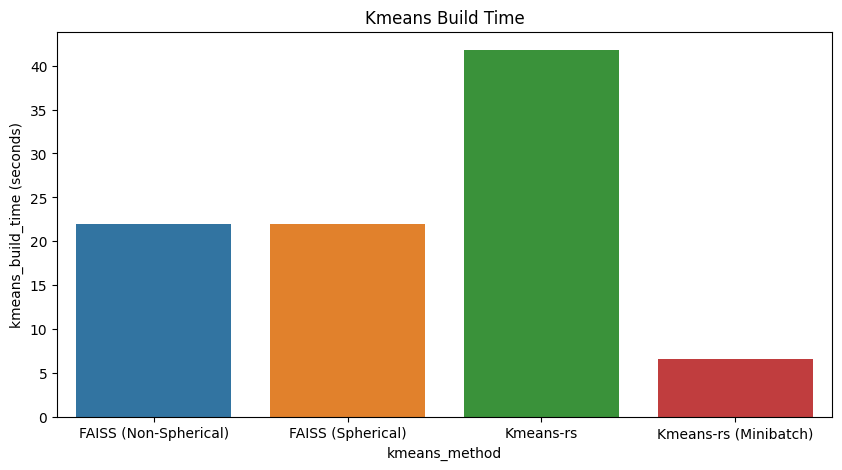

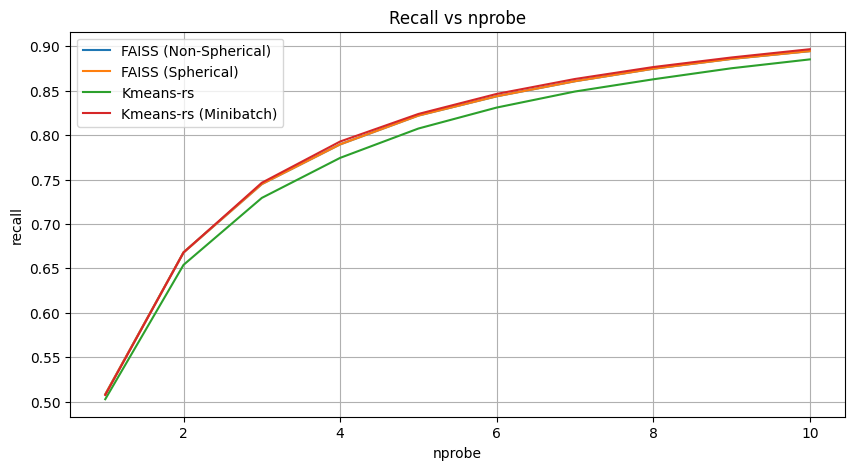

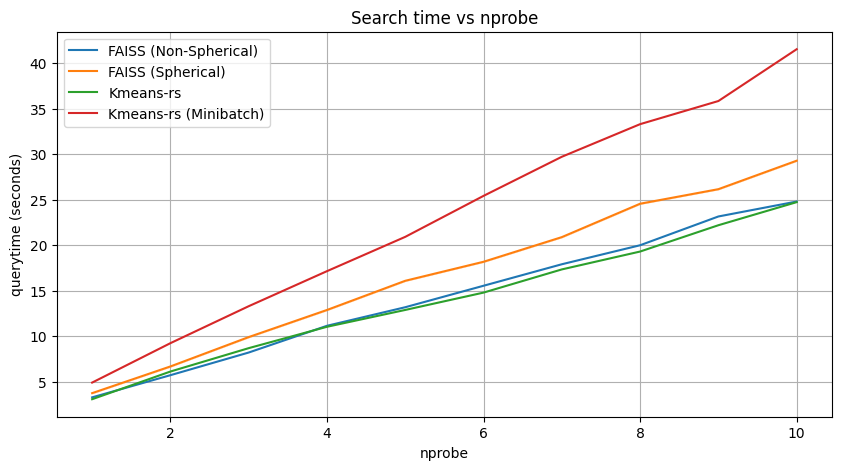

In [62]:
method_dataframes = analyze_kmeans_methods(df)